In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
F = GF(2)
MS = MatrixSpace(F, 2)
matrices = list(MS)

In [3]:
def format_matrix_label(m):
    return f"[{m[0,0]} {m[0,1]}]\n[{m[1,0]} {m[1,1]}]"

In [4]:
G = nx.Graph()
nodes = [format_matrix_label(m) for m in matrices]
G.add_nodes_from(nodes)

In [5]:
n = len(matrices)
for i in range(n):
    for j in range(i+1, n):
        A = matrices[i]
        B = matrices[j]
        if (A-B).rank() == 1:
            G.add_edge(nodes[i], nodes[j])

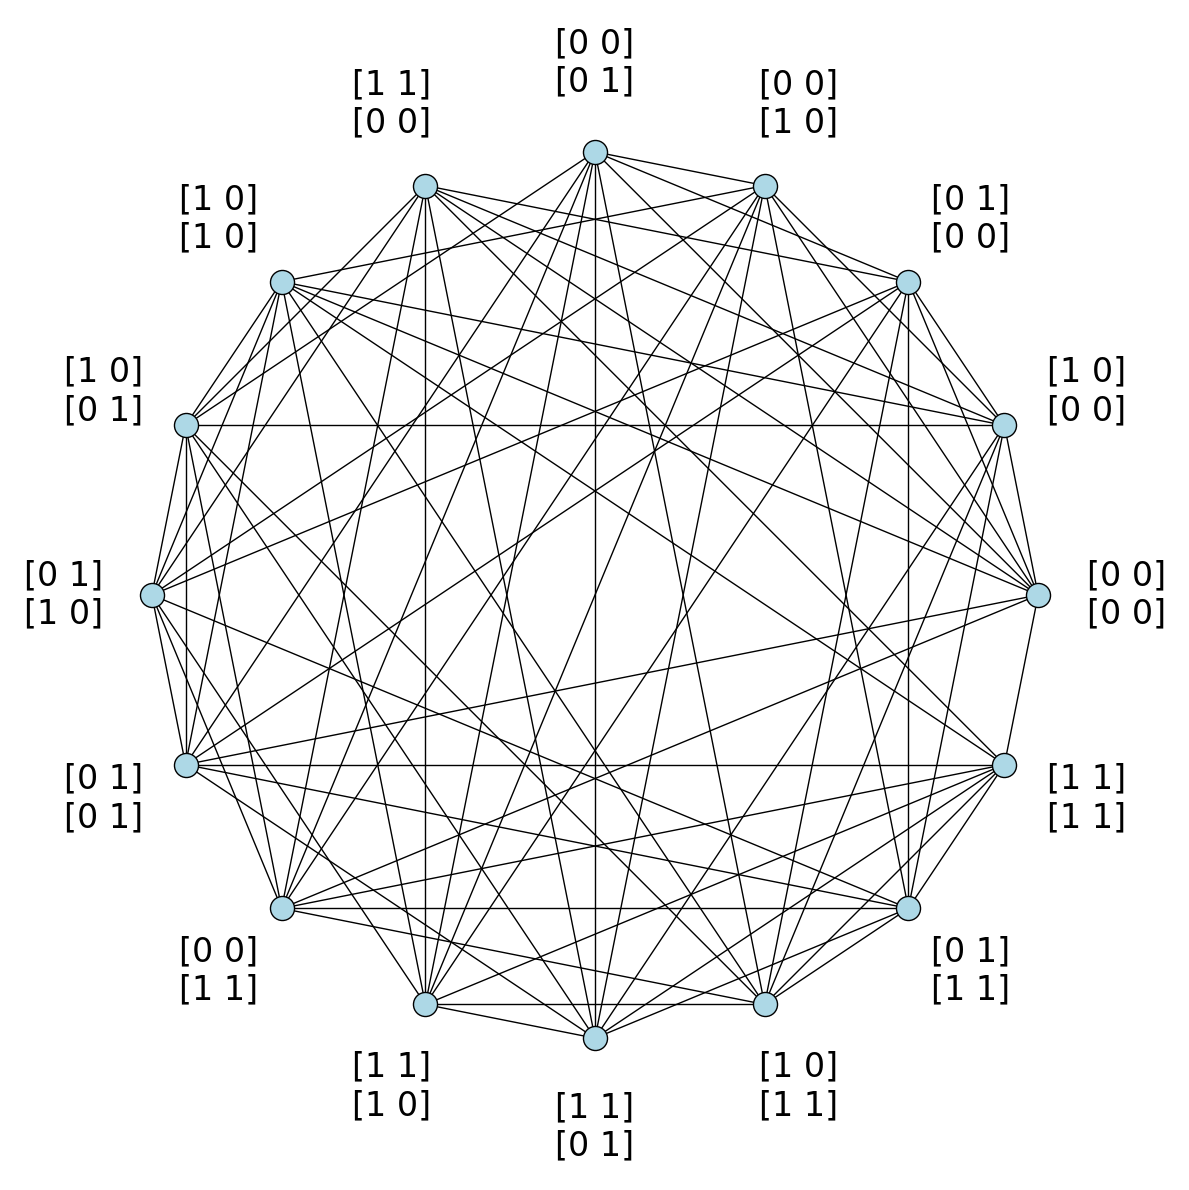

In [6]:
# 1. Calculate the base circular layout for the nodes
pos = nx.circular_layout(G)

# 2. Create a new dictionary for label positions by pushing them outward
label_pos = {}
for node, (x, y) in pos.items():
    # Multiply by 1.2 to push the label 20% further out from the center
    label_pos[node] = (x * 1.2, y * 1.2)

# 3. Draw the graph
plt.figure(figsize=(12, 12))

# Make the nodes smaller since they don't need to hold text anymore
nx.draw_networkx_nodes(G, pos, node_color='lightblue', edgecolors='black')
nx.draw_networkx_edges(G, pos)

# Draw the labels using the new label_pos dictionary and a larger font size
nx.draw_networkx_labels(G, label_pos, font_size=24)

# 4. Expand the margins so the outer labels don't get cut off by the edge of the image
plt.margins(0.1)
plt.axis("off")
plt.tight_layout()
plt.show()